<a href="https://colab.research.google.com/github/meenakshi-kay/Orbit-Simulation/blob/main/keplers_laws_verification_and_exoplanet_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importing required code cells from the numerical method comparison notebook

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [101]:
G = 6.67408e-11

M_star = 1.9891e30
M_planet = 5.9722e24

e = 0.0167
a = 1.496e11

In [102]:
T_estimate = (4*(math.pi**2)*(a**3)/(G*M_star))**0.5
print("Estimated time period (in days):", T_estimate/(60*60*24))

dt = T_estimate / 10000
n_orbits = 5
n_steps = int((T_estimate/dt) * n_orbits)

Estimated time period (in days): 365.2073450064896


In [103]:
r_peri = a * (1 - e)
initial_pos = np.array([r_peri, 0.0])

init_vel_magnitude = np.sqrt(G * M_star * ((2/r_peri) - (1/a)))
initial_vel = np.array([0.0, init_vel_magnitude])

In [104]:
def calc_acceleration(pos):
    r = np.linalg.norm(pos)
    return -G * M_star * pos / r**3

In [105]:
# the method that gave us the best energy conservation for the number of orbits we selected
# was the RK4 method. so we're importing just the code for that to do our verifications to simplify the process
def rk4(pos, vel, dt, n_steps):
    positions = []
    velocities = []
    times = []

    pos = pos.copy()
    vel = vel.copy()

    for i in range(n_steps):
        k1_pos = vel
        k1_vel = calc_acceleration(pos)

        k2_pos = vel + 0.5 * k1_vel * dt
        k2_vel = calc_acceleration(pos + 0.5 * k1_pos * dt)

        k3_pos = vel + 0.5 * k2_vel * dt
        k3_vel = calc_acceleration(pos + 0.5 * k2_pos * dt)

        k4_pos = vel + k3_vel * dt
        k4_vel = calc_acceleration(pos + k3_pos * dt)

        pos = pos + (dt / 6) * (k1_pos + 2*k2_pos + 2*k3_pos + k4_pos)
        vel = vel + (dt / 6) * (k1_vel + 2*k2_vel + 2*k3_vel + k4_vel)

        positions.append(pos.copy())
        velocities.append(vel.copy())
        times.append(i * dt)

    return np.array(positions), np.array(velocities), np.array(times)   #also returning velocities this time for period and 2nd law claculations

In [106]:
positions, velocities, times = rk4(initial_pos, initial_vel, dt, n_steps)   #running the simulation
#quick note check number of seconds to run the code. it's around 2s every time, which, compared to the other ones
# of 0s is clearly a lot more computationally expensive.

#VERIFICATION OF KEPLER'S FIRST LAW

According to Kepler's First Law, planets move in elliptical orbits with the Sun located at one focus of the ellipse.

To test this, I calculate the periapsis and apoapsis distances directly from the simulated orbit. These values can then be used to estimate the semi-major axis and eccentricity of the orbit.

If the calculated values match the original input parameters reasonably well, it would suggest that the simulation is reproducing the expected orbital geometry correctly.

To verify Kepler's First Law, I first calculated the planet's distance from the star at every timestep.

Since the star is fixed at the origin, this distance can be calculated from the x and y coordinates of the planet using:

r = √(x² + y²)

This does not assume that the orbit is circular. It only gives the instantaneous distance of the planet from the star.

The minimum distance gives the periapsis and the maximum distance gives the apoapsis. These values are then used to calculate the semi-major axis and eccentricity of the simulated orbit.

- For every position vector, r = sqrt(x^2 + y^2)
- Periapsis and apoapsis: rp = min(r) and ra = max(r)
- Semi-major axis. For an ellipse: a = (ra+rp)/2\
(compaering with our assumed a = 1.496e11)
- eccentricity: e = (ra-rp)/(ra+rp) for elliptical orbit

In [107]:
# distance of planet from star at every timestep

r = np.linalg.norm(positions, axis=1)   #sqrt(x^2 + y^2)

# periapsis and apoapsis distances
r_peri_sim = np.min(r)
r_apo_sim = np.max(r)

# semi-major axis from simulated orbit
a_sim = (r_peri_sim + r_apo_sim)/2

# eccentricity from simulated orbit
e_sim = (r_apo_sim - r_peri_sim) / (r_apo_sim + r_peri_sim)

print("Input semi-major axis (m):", a)
print("Simulated semi-major axis (m):", a_sim,'\n')


print("Input eccentricity:", e)
print("Simulated eccentricity:", e_sim,'\n')


print("Percentage error in a:", abs(a_sim - a)/a * 100)
print("Percentage error in e:", abs(e_sim - e)/e * 100)

Input semi-major axis (m): 149600000000.0
Simulated semi-major axis (m): 149600000000.00177 

Input eccentricity: 0.0167
Simulated eccentricity: 0.016700000000023772 

Percentage error in a: 1.1831681358622995e-12
Percentage error in e: 1.423512006873423e-10


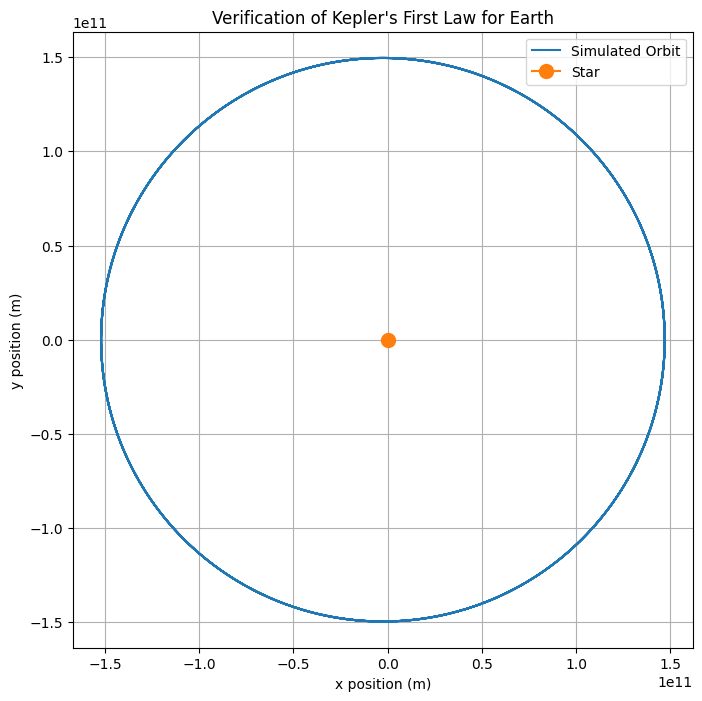

In [163]:
plt.figure(figsize=(8,8))

plt.plot(positions[:,0], positions[:,1], label="Simulated Orbit")
plt.plot(0, 0, marker='o', markersize=10, label="Star")

plt.axis("equal")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Verification of Kepler's First Law for Earth")
plt.legend()
plt.grid()

plt.show()

| Parameter           | Input Value  | Simulated Value    | % Error      |
| ------------------- | ------------ | ------------------ | ------------ |
| Semi-major axis (m) | 1.496 × 10¹¹ | 1.496 × 10¹¹       | 1.18 × 10⁻¹² |
| Eccentricity        | 0.0167       | 0.0167000000000238 | 1.42 × 10⁻¹⁰ |


The simulated orbit appears nearly circular because Earth's eccentricity is relatively small (e = 0.0167), although the numerical analysis confirms that the orbit is elliptical.

Since Earth’s orbit has a very small eccentricity and appears almost circular, Mercury was also simulated to provide a clearer visual verification of the elliptical nature of planetary orbits.

In [130]:
# MERCURY ORBIT FOR VISUAL VERIFICATION OF KEPLER'S FIRST LAW

merc_a = 5.791e10          # semi-major axis (m)
merc_e = 0.2056            # eccentricity

merc_r_peri = merc_a * (1 - merc_e)

merc_initial_pos = np.array([
    merc_r_peri,
    0.0
])

merc_initial_speed = np.sqrt(
    G * M_star *
    ((2 / merc_r_peri) - (1 / merc_a))
)

merc_initial_vel = np.array([
    0.0,
    merc_initial_speed
])

merc_T = np.sqrt(
    (4 * np.pi**2 * merc_a**3) /
    (G * M_star)
)

merc_dt = merc_T / 10000
merc_n_steps = int(2 * merc_T / merc_dt)

In [132]:
merc_positions, merc_velocities, merc_times = rk4(
    merc_initial_pos,
    merc_initial_vel,
    merc_dt,
    merc_n_steps
)

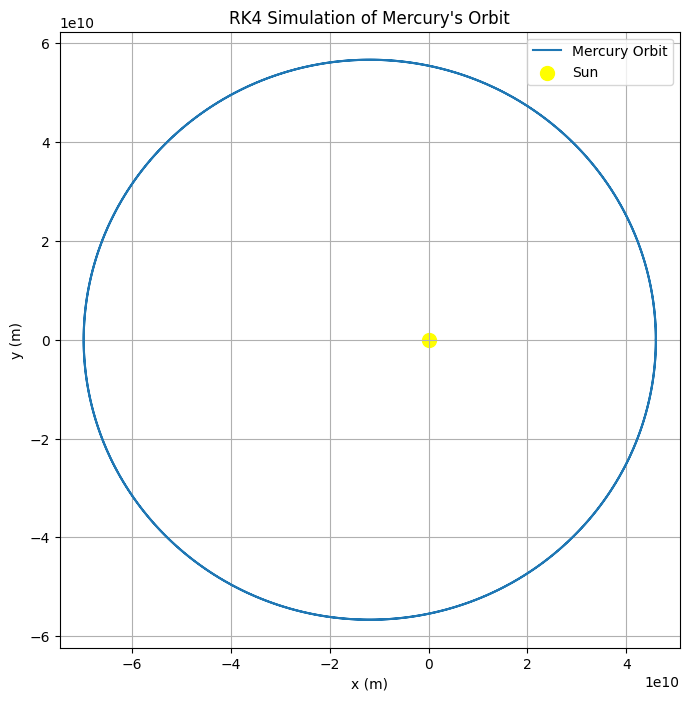

In [134]:
plt.figure(figsize=(8,8))

plt.plot(
    merc_positions[:,0],
    merc_positions[:,1],
    label="Mercury Orbit"
)

plt.scatter(
    0,
    0,
    marker='o',
    s=100,
    label="Sun",
    color="yellow"
)

plt.axis("equal")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("RK4 Simulation of Mercury's Orbit")
plt.legend()
plt.grid()

plt.show()

In [135]:
merc_r = np.linalg.norm(merc_positions, axis=1)

merc_r_peri_sim = np.min(merc_r)
merc_r_apo_sim = np.max(merc_r)

merc_a_sim = (merc_r_peri_sim + merc_r_apo_sim) / 2

merc_e_sim = (
    merc_r_apo_sim - merc_r_peri_sim
) / (
    merc_r_apo_sim + merc_r_peri_sim
)

print("Input eccentricity:", merc_e)
print("Simulated eccentricity:", merc_e_sim)

print("Input semi-major axis:", merc_a)
print("Simulated semi-major axis:", merc_a_sim)

Input eccentricity: 0.2056
Simulated eccentricity: 0.2056000000000069
Input semi-major axis: 57910000000.0
Simulated semi-major axis: 57909999999.998985


Since Earth's eccentricity is relatively small (e = 0.0167), the simulated orbit appears nearly circular. To provide a clearer visual demonstration of Kepler's First Law, Mercury's orbit (e = 0.2056) was also simulated using RK4. The resulting trajectory clearly exhibits an elliptical shape with the Sun located at one focus.

#VERIFICATION OF KEPLER'S SECOND LAW

The next step is to verify Kepler's Second Law.

Kepler's Second Law states that a line joining a planet and the Sun sweeps out equal areas in equal intervals of time. This means that a planet moves faster when it is closer to the Sun and slower when it is farther away, but the rate at which area is swept out remains constant.

To test this, the area swept by the radius vector is calculated at different points throughout the orbit. Rather than comparing the speed of the planet directly, the swept area is used as the verification metric.

If the simulation satisfies Kepler's Second Law, equal time intervals should produce approximately equal swept areas irrespwective of where the planet is located in its orbit.

The area swept between two consecutive position vectors can be approximated using the area of a triangle:

A = 1/2 |r₁ × r₂|

where r₁ and r₂ are the position vectors of the planet at consecutive timesteps.

The total swept area over a larger time interval is obtained by summing many of these small triangular areas.

If Kepler's Second Law is satisfied, the swept area per unit time should remain approximately constant throughout the orbit.

In [109]:
# position vectors at consecutive timesteps

r1 = positions[:-1]
r2 = positions[1:]

# area swept between consecutive position vectors
# A = 1/2 |r1 x r2|

small_areas = 0.5 * np.abs(r1[:, 0] * r2[:, 1] - r1[:, 1] * r2[:, 0])

Since the timestep used in the simulation is very small, the area swept between two consecutive position vectors is also very small.

To make the comparison clearer, I am grouping these small areas into equal time intervals and summing them. Each summed value represents the area swept during the same amount of time.

In [110]:
# grouping small swept areas into equal time intervals

n_chunks = 100
chunk_size = len(small_areas) // n_chunks

swept_areas = []
chunk_times = []

for i in range(n_chunks):
    start = i * chunk_size
    end = (i + 1) * chunk_size

    swept_areas.append(np.sum(small_areas[start:end]))
    chunk_times.append(times[start] / (60 * 60 * 24))  # converting seconds to days

swept_areas = np.array(swept_areas)
chunk_times = np.array(chunk_times)

In [111]:
# calculating percentage deviation from the mean swept area

mean_area = np.mean(swept_areas)

percentage_deviation = ((swept_areas - mean_area) / mean_area) * 100

print("Mean swept area:", mean_area)
print("Minimum swept area:", np.min(swept_areas))
print("Maximum swept area:", np.max(swept_areas))
print("Maximum percentage deviation:",
      np.max(np.abs(percentage_deviation)), "%")

Mean swept area: 3.50794687857147e+21
Minimum swept area: 3.5079468668085045e+21
Maximum swept area: 3.507946889736381e+21
Maximum percentage deviation: 3.353233620994339e-07 %


If Kepler's Second Law is satisfied, the swept areas calculated over equal time intervals should remain approximately constant throughout the orbit.


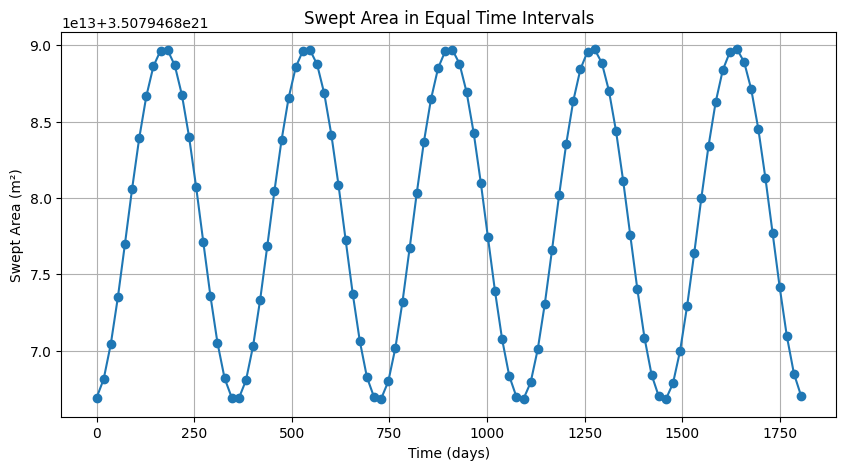

In [112]:
plt.figure(figsize=(10,5))

plt.plot(
    chunk_times,
    swept_areas,
    marker='o'
)

plt.xlabel("Time (days)")
plt.ylabel("Swept Area (m²)")
plt.title("Swept Area in Equal Time Intervals")
plt.grid()

plt.show()

Instead of plotting just the raw swept areas, I am plotting the percentage deviation from the mean swept area.

This makes the variation easier to interpret because the actual swept area values are very large. If Kepler's Second Law is satisfied, the percentage deviation should remain very close to zero.

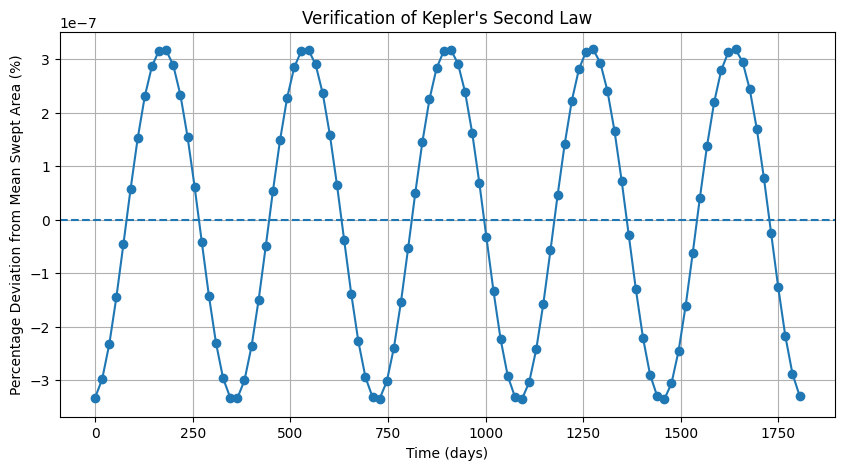

In [113]:
plt.figure(figsize=(10,5))

plt.plot(chunk_times, percentage_deviation, marker='o')
plt.axhline(0, linestyle='--')

plt.xlabel("Time (days)")
plt.ylabel("Percentage Deviation from Mean Swept Area (%)")
plt.title("Verification of Kepler's Second Law")
plt.grid()

plt.show()

Although the swept area plot shows small oscillations, the maximum percentage deviation from the mean swept area is very small. This indicates that equal areas are swept in approximately equal time intervals, supporting Kepler’s Second Law.

In [114]:
print("Mean swept area:", mean_area)
print("Minimum swept area:", np.min(swept_areas))
print("Maximum swept area:", np.max(swept_areas))
print("Range:", np.max(swept_areas) - np.min(swept_areas))

print("Maximum percentage deviation:",
      np.max(np.abs(percentage_deviation)), "%")

Mean swept area: 3.50794687857147e+21
Minimum swept area: 3.5079468668085045e+21
Maximum swept area: 3.507946889736381e+21
Range: 22927876554752.0
Maximum percentage deviation: 3.353233620994339e-07 %


The maximum percentage deviation was 3.35×10^−7%, which is negligible enough that we can say Kepler's 2nd Law has been verified for this particular project.

#VERIFICATION OF KEPLER'S THIRD LAW

Verification of Kepler's Third Law

Kepler's Third Law states that the square of the orbital period is proportional to the cube of the semi-major axis:

T² ∝ a³

To verify this relationship, I simulated the orbits of the eight planets in the Solar System using the RK4 method.

Unlike the previous simulations, each planet was assigned its own published semi-major axis and eccentricity. This allows the simulations to more closely represent the actual planetary orbits while retaining the same two-body approximation used throughout the study.

In [150]:
planet_names = np.array([
    "Mercury",
    "Venus",
    "Earth",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
])

a_AU = np.array([
    0.387,
    0.723,
    1.000,
    1.524,
    5.203,
    9.537,
    19.191,
    30.069
])

planet_e = np.array([
    0.2056,
    0.0068,
    0.0167,
    0.0934,
    0.0489,
    0.0565,
    0.0472,
    0.0086
])

observed_period_days = np.array([
    87.97,
    224.70,
    365.25,
    686.98,
    4332.59,
    10759.22,
    30688.5,
    60182
])

The RK4 algorithm itself remains unchanged from the implementation used earlier. But, the simulation is now repeated for multiple planets using their individual orbital parameters.

For each planet, the periapsis distance is calculated from the semi-major axis and eccentricity. Then the vis-viva equation is used to find the initial velocity required to generate the orbit.

The simulation is continued until one complete revolution is detected (chhceck initial and final conditions). The time required to complete this revolution is recorded as the simulated orbital period.

In [155]:
def simulate_period_rk4(a_AU_value, e_value):

    a = a_AU_value * AU

    T_estimate = np.sqrt((4 * np.pi**2 * a**3) / (G * M_sun))

    dt = T_estimate / 10000
    n_steps = int(1.2 * T_estimate / dt)

    r_peri = a * (1 - e_value)

    pos = np.array([r_peri, 0.0])

    speed = np.sqrt(G * M_sun * ((2 / r_peri) - (1 / a)))

    vel = np.array([0.0, speed])

    positions = []
    times = []

    for i in range(n_steps):

        k1_pos = vel
        k1_vel = -G * M_sun * pos / np.linalg.norm(pos)**3

        k2_pos = vel + 0.5 * k1_vel * dt
        k2_vel = -G * M_sun * (pos + 0.5 * k1_pos * dt) / np.linalg.norm(pos + 0.5 * k1_pos * dt)**3

        k3_pos = vel + 0.5 * k2_vel * dt
        k3_vel = -G * M_sun * (pos + 0.5 * k2_pos * dt) / np.linalg.norm(pos + 0.5 * k2_pos * dt)**3

        k4_pos = vel + k3_vel * dt
        k4_vel = -G * M_sun * (pos + k3_pos * dt) / np.linalg.norm(pos + k3_pos * dt)**3

        pos = pos + (dt / 6) * (k1_pos + 2*k2_pos + 2*k3_pos + k4_pos)
        vel = vel + (dt / 6) * (k1_vel + 2*k2_vel + 2*k3_vel + k4_vel)

        positions.append(pos.copy())
        times.append(i * dt)

    positions = np.array(positions)
    times = np.array(times)

    angles = np.unwrap(np.arctan2(positions[:,1], positions[:,0]))

    completed = np.where(angles >= 2*np.pi)[0]

    simulated_period_days = (times[completed[0]] / 86400)

    return simulated_period_days

In [153]:
simulated_period_days = []

for a_value, e_value in zip(a_AU, planet_e):
    simulated_period_days.append(simulate_period_rk4(a_value, e_value))

simulated_period_days = np.array(simulated_period_days)

percentage_error = (np.abs(simulated_period_days - observed_period_days) / observed_period_days) * 100

In [154]:
kepler3_results = pd.DataFrame({
    "Planet": planet_names,
    "Semi-major axis (AU)": a_AU,
    "Eccentricity": planet_e,
    "Observed Period (days)": observed_period_days,
    "Simulated Period (days)": simulated_period_days,
    "Percentage Error (%)": percentage_error
})

kepler3_results

,Planet,Semi-major axis (AU),Eccentricity,Observed Period (days),Simulated Period (days),Percentage Error (%)
0,Mercury,0.387,0.2056,87.97,87.914907,0.062627
1,Venus,0.723,0.0068,224.70,224.493369,0.091959
2,Earth,1.000,0.0167,365.25,365.207345,0.011678
3,Mars,1.524,0.0934,686.98,687.026553,0.006776
4,Jupiter,5.203,0.0489,4332.59,4333.879288,0.029758
5,Saturn,9.537,0.0565,10759.22,10755.082491,0.038455
6,Uranus,19.191,0.0472,30688.50,30700.290145,0.038419
7,Neptune,30.069,0.0086,60182.00,60210.821054,0.047890


The simulated periods are compared with the observed orbital periods of the planets.

If the numerical model correctly reproduces Kepler's Third Law, the simulated and observed periods should agree closely despite the wide range of orbital sizes represented in the Solar System.

In [156]:
print("The average percentage error is",np.mean(percentage_error),"%")

The average percentage error is 0.04094533314489893 %


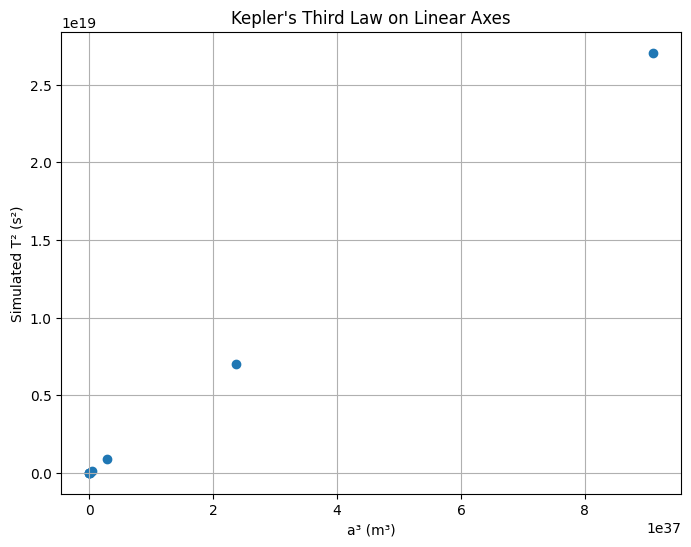

In [161]:
AU = 1.496e11

# converting semi-major axis from AU to metres
a_m = a_AU * AU

# calculating a^3 and T^2
a_cubed = a_m**3
T_squared = (simulated_period_days * 86400)**2

# linear scale plot
plt.figure(figsize=(8,6))

plt.scatter(a_cubed, T_squared)

plt.xlabel("a³ (m³)")
plt.ylabel("Simulated T² (s²)")
plt.title("Kepler's Third Law on Linear Axes")
plt.grid()

plt.show()

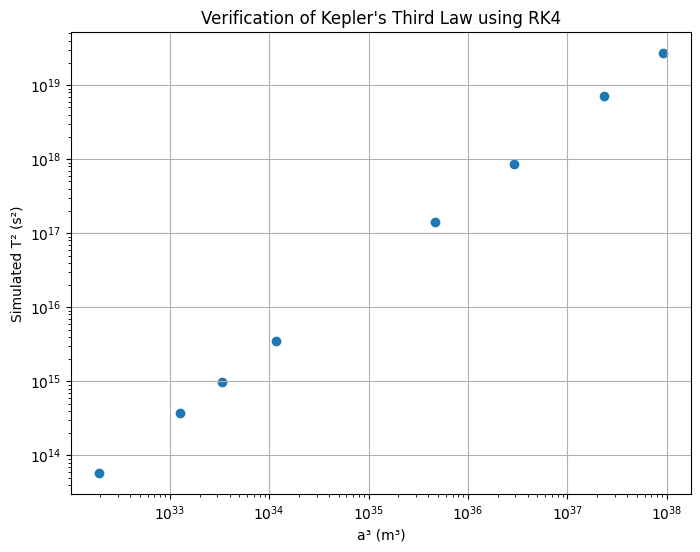

In [162]:
a_m = a_AU * AU

a_cubed = a_m**3
T_squared = (simulated_period_days * 86400)**2

plt.figure(figsize=(8,6))

plt.scatter(a_cubed, T_squared)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("a³ (m³)")
plt.ylabel("Simulated T² (s²)")
plt.title("Verification of Kepler's Third Law using RK4")
plt.grid()

plt.show()

| Law        | Verification Method   | Result                               |
| ---------- | --------------------- | ------------------------------------ |
| First Law  | Recovery of a and e   | Successfully verified                |
| Second Law | Swept area analysis   | Max deviation (3.35 \times 10^{-7}%) |
| Third Law  | RK4 period comparison | Avg error ~0.04%                     |


#EXOPLANET COMPARISON


Comparison with Exoplanet Data

After verifying the model using Solar System planets, I am now comparing the calculated orbital periods with observed data for selected exoplanets.

For each exoplanet, the semi-major axis and host star mass are used to calculate the expected orbital period using Kepler's Third Law. This calculated period is then compared with the observed period.

This helps check whether the same orbital relationship works for planetary systems outside the Solar System.

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

planet_names = np.array([
    "51 Pegasi b",
    "Kepler-10 b",
    "TRAPPIST-1 e",
    "Proxima Centauri b",
    "WASP-12 b",
    "Kepler-22 b"
])

star_names = np.array([
    "51 Pegasi",
    "Kepler-10",
    "TRAPPIST-1",
    "Proxima Centauri",
    "WASP-12",
    "Kepler-22"
])

a_AU = np.array([
    0.052,
    0.01685,
    0.02925,
    0.0485,
    0.0234,
    0.812
])

observed_period_days = np.array([
    4.23,
    0.837491,
    6.1,
    11.2,
    1.09,
    289.9
])

stellar_mass_solar = np.array([
    1.09,
    0.9,
    0.089,
    0.122,
    1.35,
    0.857
])

The orbital period is calculated using Kepler's Third Law:

T = √(4π²a³ / GM)

Here, a is the semi-major axis of the exoplanet orbit and M is the mass of the host star.

Since the data gives semi-major axis in AU and stellar mass in solar masses, these values are first converted to SI units.

In [126]:
G = 6.67408e-11
AU = 1.496e11
M_sun = 1.9891e30

a_m = a_AU * AU
stellar_mass_kg = stellar_mass_solar * M_sun

calculated_period_s = np.sqrt((4 * np.pi**2 * a_m**3) / (G * stellar_mass_kg))
calculated_period_days = calculated_period_s / (60 * 60 * 24)

percentage_error = (np.abs(calculated_period_days - observed_period_days) / observed_period_days) * 100

In [127]:
exoplanet_results = pd.DataFrame({
    "Planet": planet_names,
    "Host Star": star_names,
    "Semi-major axis (AU)": a_AU,
    "Observed Period (days)": observed_period_days,
    "Calculated Period (days)": calculated_period_days,
    "Percentage Error (%)": percentage_error
})

exoplanet_results

,Planet,Host Star,Semi-major axis (AU),Observed Period (days),Calculated Period (days),Percentage Error (%)
0,51 Pegasi b,51 Pegasi,0.05200,4.230000,4.147929,1.940223
1,Kepler-10 b,Kepler-10,0.01685,0.837491,0.842012,0.539786
2,TRAPPIST-1 e,TRAPPIST-1,0.02925,6.100000,6.123974,0.393009
3,Proxima Centauri b,Proxima Centauri,0.04850,11.200000,11.167917,0.286451
4,WASP-12 b,WASP-12,0.02340,1.090000,1.125114,3.221439
5,Kepler-22 b,Kepler-22,0.81200,289.900000,288.657693,0.428529


To visualise the comparison, the observed orbital periods are plotted against the calculated orbital periods.

If the calculated values agree well with the observed data, the points should lie close to the dashed line representing perfect agreement.

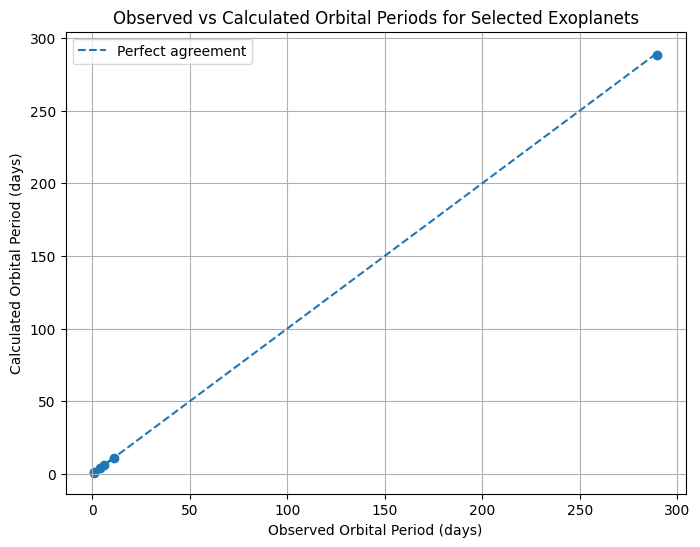

In [128]:
plt.figure(figsize=(8,6))

plt.scatter(
    observed_period_days,
    calculated_period_days
)

plt.plot(
    observed_period_days,
    observed_period_days,
    linestyle="--",
    label="Perfect agreement"
)

plt.xlabel("Observed Orbital Period (days)")
plt.ylabel("Calculated Orbital Period (days)")
plt.title("Observed vs Calculated Orbital Periods for Selected Exoplanets")
plt.legend()
plt.grid()

plt.show()

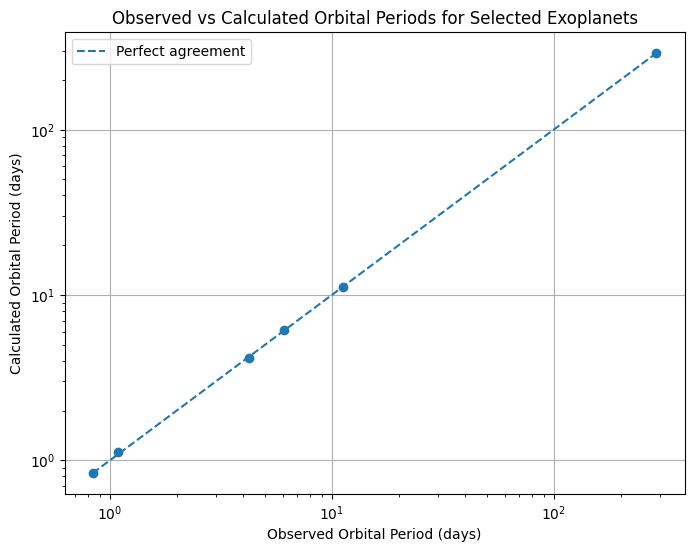

In [129]:
plt.figure(figsize=(8,6))

plt.scatter(
    observed_period_days,
    calculated_period_days
)

x = np.linspace(
    np.min(observed_period_days),
    np.max(observed_period_days),
    100
)

plt.plot(
    x,
    x,
    linestyle="--",
    label="Perfect agreement"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Observed Orbital Period (days)")
plt.ylabel("Calculated Orbital Period (days)")
plt.title("Observed vs Calculated Orbital Periods for Selected Exoplanets")

plt.legend()
plt.grid()

plt.show()

The calculated orbital periods closely follow the line of perfect agreement, indicating good agreement between the model predictions and the observed exoplanet data over a wide range of orbital periods.

The calculated orbital periods showed good agreement with the observed values for all selected exoplanets. The percentage error remained below 4% for every system considered, with most planets exhibiting errors below 1%. The largest deviation was observed for WASP-12 b, while the smallest deviation was observed for Proxima Centauri b. Overall, the results suggest that the model is capable of reproducing the orbital characteristics of real exoplanetary systems with reasonable accuracy despite the simplifying assumptions of the two-body approximation.

In [136]:
print("Average percentage error:",
      np.mean(percentage_error))

Average percentage error: 1.1349061859226441
